In [2]:
import pandas as pd
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import Metadata
import torch
torch.cuda.is_available()

True

In [3]:
data = pd.read_csv('input/PERSON_SALARY.csv')
data = data.dropna()
data = data.drop(columns=['GEOGRAPHY_POINT', 'POP_SCORE','LATITUDE','LONGITUDE','DIM_PERSON_KEY']).sample(n=30000)
# data['ZIP'] = data['ZIP'].astype(str).str.zfill(5)
data['DIM_OCCUPATION_KEY'] = data['DIM_OCCUPATION_KEY'].astype(str)

# Reorder to see if column order prioritizes relationships
data = data.reindex(columns=['DIM_OCCUPATION_KEY', 'FINAL_SALARY', 'ZIP', 'GENDER', 'APPROX_AGE', 'CITY', 'STATE', 'FIRST_NAME', 'LAST_NAME', 'TYPE', 'ADDRESS'])
data

,DIM_OCCUPATION_KEY,FINAL_SALARY,ZIP,GENDER,APPROX_AGE,CITY,STATE,FIRST_NAME,LAST_NAME,TYPE,ADDRESS
85082,332011,47147,54022,Female,73,River Falls,WI,Susanna,Siegel,OTHER,100 Main Street
31321,499041,59675,16025,Male,39,Chicora,PA,Jeff,Wolfert,ATH,521 Main Street
87708,431011,134171,53202,Male,33,Milwaukee,WI,Bizzy,Crook,MUS,1910 Farwell Avenue
5165,252031,138471,83501,Male,61,Lewiston,ID,Rich,Lesser,OTHER,915 Cypress Street
65402,393031,106499,92625,Female,50,Newport Beach,CA,Dylan,Lauren,OTHER,3451 Coast Highway
...,...,...,...,...,...,...,...,...,...,...,...
90711,436014,50517,58501,Male,51,Bismarck,ND,David,Ury,ACT,2523 Railroad Avenue
31454,333012,71537,26059,Male,65,Triadelphia,WV,Dennis,Chambers,OTHER,465 Cabela Drive
61453,291051,115423,33701,Male,43,St Petersburg,FL,Cardell,Butler,ATH,1068 4th Street
64526,132011,67648,92103,Male,69,San Diego,CA,Cam,Gordon,POL,1278 University Avenue


In [4]:
metadata = Metadata.detect_from_dataframe(data)

# Update columns with some more specific information
metadata.update_column(
    column_name='FIRST_NAME',
    sdtype='first_name',
    pii=True)

metadata.update_column(
    column_name='LAST_NAME',
    sdtype='last_name',
    pii=True)

metadata.update_column(
    column_name='ADDRESS',
    sdtype='street_address',
    pii=True)

metadata.update_column(
    column_name='CITY',
    sdtype='city',
    pii=False)

metadata.update_column(
    column_name='STATE',
    sdtype='state',
    pii=False)

metadata.update_column(
    column_name='ZIP',
    sdtype='postcode',
    pii=False)

metadata.update_column(
    column_name='FINAL_SALARY',
    sdtype='numerical',
    computer_representation='Int64')

metadata.update_column(
    column_name='DIM_OCCUPATION_KEY',
    sdtype='categorical')

In [5]:
print(metadata)

{
    "tables": {
        "table": {
            "columns": {
                "DIM_OCCUPATION_KEY": {
                    "sdtype": "categorical"
                },
                "FINAL_SALARY": {
                    "sdtype": "numerical",
                    "computer_representation": "Int64"
                },
                "ZIP": {
                    "sdtype": "postcode",
                    "pii": false
                },
                "GENDER": {
                    "sdtype": "categorical"
                },
                "APPROX_AGE": {
                    "sdtype": "numerical"
                },
                "CITY": {
                    "sdtype": "city",
                    "pii": false
                },
                "STATE": {
                    "sdtype": "state",
                    "pii": false
                },
                "FIRST_NAME": {
                    "sdtype": "first_name",
                    "pii": true
                },
                "LAS

In [6]:
synthesizer = CTGANSynthesizer(metadata, cuda=True, epochs=150)
synthesizer.fit(data)


C:\Users\BrittonGray\anaconda3\envs\synthetic_data\Lib\site-packages\sdv\single_table\base.py:133: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



In [7]:
synthesizer.save(
    filepath='ctgan_20250815.pkl'
)

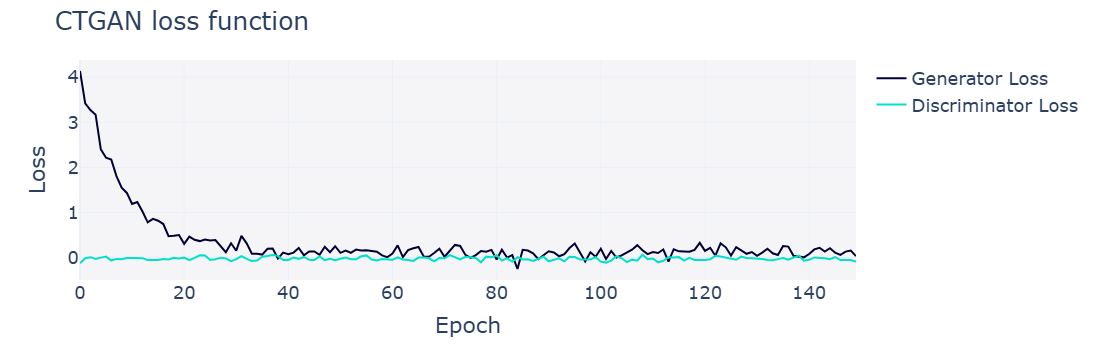

In [8]:
fig = synthesizer.get_loss_values_plot()
fig.show()

In [9]:
synthetic_data = synthesizer.sample(num_rows=105000).to_csv('output/sdv_ctgan/PERSON_SALARY.csv')
synthetic_data